# **Problema**
**Queremos almacenar en una base de datos propia los datos de niveles de NO2 del aire de Madrid durante el año 2018. El objetivo es que otros departamentos puedan:**
 **- Hacer una visualización de la evolución de la contaminación: gráficas de evolución diaria / mensual, mapas de calor animados, ...**
 **- Hacer análisis de situaciones extraordinarias: días con restricciones, medición de la efectividad de ciertas medidas, ...**

**Los datos están disponibles en el portal de datos abiertos de Madrid. Asegúrate de consultar el PDF con la documentación, te  proporcionará información de utilidad sobre el dataset. Algunos comentarios:**
**- Descarga los datos del año 2018**
**- Solo nos interesan las mediciones sobre el NO2. Puedes descartar las de otros elementos contaminantes**


### *Objetivo 1: Estadístico*
#### **Leer y tratar los datos. Debes dejarlos limpios en el formato que consideres más cómodo para su análisis.**

Vamos a hacer una limpieza de los datos como se nos comenta. En la documentación, vemos que el dato del NO2 es la Magnitud 8, así que filtraremos primero por ahí. Pero antes, vamos a leer todos los archivos, empezando por hacer un DataFrame con todos los datos concatenados. 

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [47]:
ruta = os.getcwd() + '/2018'
archivos = os.listdir(ruta)
archivos_csv = [archivo for archivo in archivos if archivo.endswith('.csv')] # filtramos solamente para los .csv
# nota: cuando se descargue este notebook, se deben descargar los archivos .csv en una carpeta llamada /2018, como dejaré subido en el repositorio

In [48]:
# concatenamos todos los archivos en un solo DataFrame, teniendo ; como separador
for archivo in archivos_csv:
    df = pd.read_csv(ruta + '/' + archivo, sep=';')
    if archivo == archivos_csv[0]:
        df_t = df
    else:
        df_t = pd.concat([df_t, df])
df_t

,PROVINCIA,MUNICIPIO,ESTACION,MAGNITUD,PUNTO_MUESTREO,ANO,MES,DIA,H01,V01,...,H20,V20,H21,V21,H22,V22,H23,V23,H24,V24
0,28,79,4,1,28079004_1_38,2018,2,1,5.00,V,...,2.00,V,2.00,V,2.00,V,1.00,V,1.00,V
1,28,79,4,1,28079004_1_38,2018,2,2,1.00,V,...,4.00,V,3.00,V,4.00,V,4.00,V,5.00,V
2,28,79,4,1,28079004_1_38,2018,2,3,5.00,V,...,2.00,V,2.00,V,2.00,V,2.00,V,1.00,V
3,28,79,4,1,28079004_1_38,2018,2,4,1.00,V,...,1.00,V,1.00,V,1.00,V,1.00,V,1.00,V
4,28,79,4,1,28079004_1_38,2018,2,5,1.00,V,...,1.00,V,1.00,V,1.00,V,1.00,V,1.00,V
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4674,28,79,60,14,28079060_14_6,2018,12,27,3.45,V,...,3.20,V,3.22,V,3.02,V,3.15,V,2.84,V
4675,28,79,60,14,28079060_14_6,2018,12,28,3.18,V,...,25.59,V,22.82,V,25.93,V,22.02,V,36.69,V
4676,28,79,60,14,28079060_14_6,2018,12,29,21.64,V,...,4.41,V,9.05,V,9.57,V,21.00,V,44.01,V
4677,28,79,60,14,28079060_14_6,2018,12,30,50.56,V,...,4.77,V,4.93,V,4.15,V,3.79,V,3.97,V


In [49]:
# filtramos los resultados de la magnitud igual a 8 que es el dióxido de nitrógeno NO2
df_filtrado = df_t[df_t['MAGNITUD'] == 8]
df_filtrado

,PROVINCIA,MUNICIPIO,ESTACION,MAGNITUD,PUNTO_MUESTREO,ANO,MES,DIA,H01,V01,...,H20,V20,H21,V21,H22,V22,H23,V23,H24,V24
84,28,79,4,8,28079004_8_8,2018,2,1,60.0,V,...,37.0,V,43.0,V,43.0,V,23.0,V,21.0,V
85,28,79,4,8,28079004_8_8,2018,2,2,18.0,V,...,49.0,V,59.0,V,81.0,V,88.0,V,87.0,V
86,28,79,4,8,28079004_8_8,2018,2,3,82.0,V,...,37.0,V,37.0,V,41.0,V,34.0,V,25.0,V
87,28,79,4,8,28079004_8_8,2018,2,4,20.0,V,...,49.0,V,44.0,V,40.0,V,29.0,V,24.0,V
88,28,79,4,8,28079004_8_8,2018,2,5,22.0,V,...,46.0,V,46.0,V,44.0,V,32.0,V,24.0,V
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4581,28,79,60,8,28079060_8_8,2018,12,27,79.0,V,...,75.0,V,90.0,V,86.0,V,67.0,V,48.0,V
4582,28,79,60,8,28079060_8_8,2018,12,28,58.0,V,...,38.0,V,38.0,V,35.0,V,36.0,V,18.0,V
4583,28,79,60,8,28079060_8_8,2018,12,29,30.0,V,...,67.0,V,59.0,V,56.0,V,42.0,V,16.0,V
4584,28,79,60,8,28079060_8_8,2018,12,30,10.0,V,...,94.0,V,92.0,V,74.0,V,87.0,V,74.0,V


En el documento nos cuentan que sólamente serán válidos los registros que tengan una V en las columnas de validación, que son las columnas que empiezan por V. Por tanto, filtramos para los registros que solamente tengan V.

In [50]:
# hallamos las columnas que empiezan con V
columnas_validacion = [col for col in df_filtrado.columns if col.startswith('V')]
# hacemos primero una comprobación de los valores que se encuentran en estas columnas
df_filtrado[columnas_validacion].value_counts()


V01  V02  V03  V04  V05  V06  V07  V08  V09  V10  V11  V12  V13  V14  V15  V16  V17  V18  V19  V20  V21  V22  V23  V24
V    V    V    V    V    V    V    V    V    V    V    V    V    V    V    V    V    V    V    V    V    V    V    V      8289
                                                                 N    V    V    V    V    V    V    V    V    V    V        46
                                                       N    V    V    V    V    V    V    V    V    V    V    V    V        45
                                             N    V    V    V    V    V    V    V    V    V    V    V    V    V    V        41
                                             V    V    V    N    V    V    V    V    V    V    V    V    V    V    V        40
                                                                                                                          ... 
                                                       N    N    N    N    V    V    V    V    V    V    V    V    V   

In [51]:
# aplicamos una función lambda para quitarnos los valores que no son V en las columnas que empiezan por V
df_total = df_filtrado[df_filtrado[columnas_validacion].apply(lambda x: all(x == 'V'), axis=1)]
df_total

,PROVINCIA,MUNICIPIO,ESTACION,MAGNITUD,PUNTO_MUESTREO,ANO,MES,DIA,H01,V01,...,H20,V20,H21,V21,H22,V22,H23,V23,H24,V24
84,28,79,4,8,28079004_8_8,2018,2,1,60.0,V,...,37.0,V,43.0,V,43.0,V,23.0,V,21.0,V
85,28,79,4,8,28079004_8_8,2018,2,2,18.0,V,...,49.0,V,59.0,V,81.0,V,88.0,V,87.0,V
86,28,79,4,8,28079004_8_8,2018,2,3,82.0,V,...,37.0,V,37.0,V,41.0,V,34.0,V,25.0,V
87,28,79,4,8,28079004_8_8,2018,2,4,20.0,V,...,49.0,V,44.0,V,40.0,V,29.0,V,24.0,V
88,28,79,4,8,28079004_8_8,2018,2,5,22.0,V,...,46.0,V,46.0,V,44.0,V,32.0,V,24.0,V
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4581,28,79,60,8,28079060_8_8,2018,12,27,79.0,V,...,75.0,V,90.0,V,86.0,V,67.0,V,48.0,V
4582,28,79,60,8,28079060_8_8,2018,12,28,58.0,V,...,38.0,V,38.0,V,35.0,V,36.0,V,18.0,V
4583,28,79,60,8,28079060_8_8,2018,12,29,30.0,V,...,67.0,V,59.0,V,56.0,V,42.0,V,16.0,V
4584,28,79,60,8,28079060_8_8,2018,12,30,10.0,V,...,94.0,V,92.0,V,74.0,V,87.0,V,74.0,V


Ahora para terminar de limpiarlos, vamos a ordenarlos. Por ejemplo lo vamos a hacer por mes y año, que estaban descoordinados. Además de quitar el innecesario dato de la magnitud una vez filtrado, y el punto de muestreo, provincia y municipio, y las columnas de validación para tener un dataset completamente limpio.

In [52]:
df_total = df_total.drop(columns = ['PROVINCIA', 'MUNICIPIO', 'MAGNITUD', 'PUNTO_MUESTREO'])
df_total = df_total.drop(columns = columnas_validacion)
df_total = df_total.sort_values(by = ['MES', 'DIA'])
df_total

,ESTACION,ANO,MES,DIA,H01,H02,H03,H04,H05,H06,...,H15,H16,H17,H18,H19,H20,H21,H22,H23,H24
93,4,2018,1,1,15.0,35.0,29.0,16.0,12.0,10.0,...,15.0,10.0,14.0,25.0,32.0,39.0,35.0,27.0,23.0,11.0
248,8,2018,1,1,33.0,64.0,63.0,51.0,57.0,45.0,...,31.0,31.0,38.0,46.0,47.0,56.0,64.0,60.0,54.0,34.0
608,11,2018,1,1,11.0,33.0,27.0,16.0,11.0,11.0,...,20.0,17.0,18.0,24.0,33.0,36.0,33.0,26.0,23.0,40.0
825,16,2018,1,1,12.0,26.0,39.0,17.0,14.0,21.0,...,20.0,29.0,27.0,27.0,36.0,39.0,38.0,53.0,59.0,35.0
980,17,2018,1,1,23.0,43.0,34.0,29.0,18.0,18.0,...,19.0,13.0,15.0,21.0,21.0,23.0,26.0,28.0,29.0,22.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4027,56,2018,12,31,73.0,62.0,51.0,46.0,47.0,47.0,...,75.0,81.0,93.0,156.0,190.0,218.0,149.0,116.0,93.0,78.0
4213,57,2018,12,31,43.0,33.0,26.0,21.0,14.0,12.0,...,59.0,90.0,84.0,98.0,127.0,199.0,187.0,166.0,112.0,81.0
4337,58,2018,12,31,22.0,20.0,18.0,14.0,10.0,10.0,...,66.0,76.0,92.0,85.0,72.0,72.0,59.0,52.0,43.0,38.0
4461,59,2018,12,31,16.0,12.0,8.0,4.0,6.0,8.0,...,65.0,65.0,58.0,70.0,87.0,113.0,118.0,108.0,68.0,41.0


In [53]:
df_total.to_csv('clean_data.csv', index = True, sep=';')

#### **Hacer una exploración de los datos. Es libre, intenta sacar algunas conclusiones de factores que puedan afectar en los niveles de NO2: estacionales, ambientales, etc.**

Pues vamos primero a ver una exploración de datos inicial general a ver si hay algo que nos sorprende y si no, vamos a especificar. 

In [54]:
df_total.describe()

,ESTACION,ANO,MES,DIA,H01,H02,H03,H04,H05,H06,...,H15,H16,H17,H18,H19,H20,H21,H22,H23,H24
count,8289.000000,8289.0,8289.000000,8289.000000,8289.000000,8289.000000,8289.000000,8289.000000,8289.000000,8289.000000,...,8289.000000,8289.000000,8289.000000,8289.00000,8289.000000,8289.000000,8289.000000,8289.000000,8289.000000,8289.000000
mean,37.844855,2018.0,6.547473,15.657136,38.453855,31.613464,25.970201,22.530945,21.118712,22.481843,...,28.470141,26.628906,27.290385,31.27446,37.497768,44.231391,50.765834,54.901798,52.582821,45.629388
std,17.643894,0.0,3.447300,8.811817,29.606767,25.727967,22.382662,19.613447,17.653864,17.143935,...,20.280968,20.298890,21.315315,24.39016,29.644841,33.622988,36.653734,37.233730,36.696586,33.937267
min,4.000000,2018.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,24.000000,2018.0,4.000000,8.000000,16.000000,12.000000,9.000000,8.000000,8.000000,9.000000,...,13.000000,12.000000,11.000000,13.00000,15.000000,19.000000,24.000000,27.000000,25.000000,20.000000
50%,40.000000,2018.0,7.000000,16.000000,29.000000,23.000000,18.000000,15.000000,15.000000,17.000000,...,23.000000,21.000000,21.000000,24.00000,29.000000,36.000000,41.000000,45.000000,42.000000,34.000000
75%,55.000000,2018.0,10.000000,23.000000,55.000000,45.000000,37.000000,32.000000,30.000000,32.000000,...,39.000000,36.000000,38.000000,44.00000,53.000000,62.000000,70.000000,74.000000,73.000000,65.000000
max,60.000000,2018.0,12.000000,31.000000,199.000000,166.000000,150.000000,140.000000,106.000000,110.000000,...,133.000000,144.000000,156.000000,200.00000,267.000000,311.000000,331.000000,308.000000,273.000000,240.000000


Nada reseñable a primera vista, por lo que vamos a hacer alguna exploración estacional. Agrupamos los datos por estación y comprobamos la media de cada medida a la hora. Además, solamente tenemos que sacar valor de las columnas con medidas, que son las que empiezan con H, por lo que las separaremos para una visualización más cómoda.

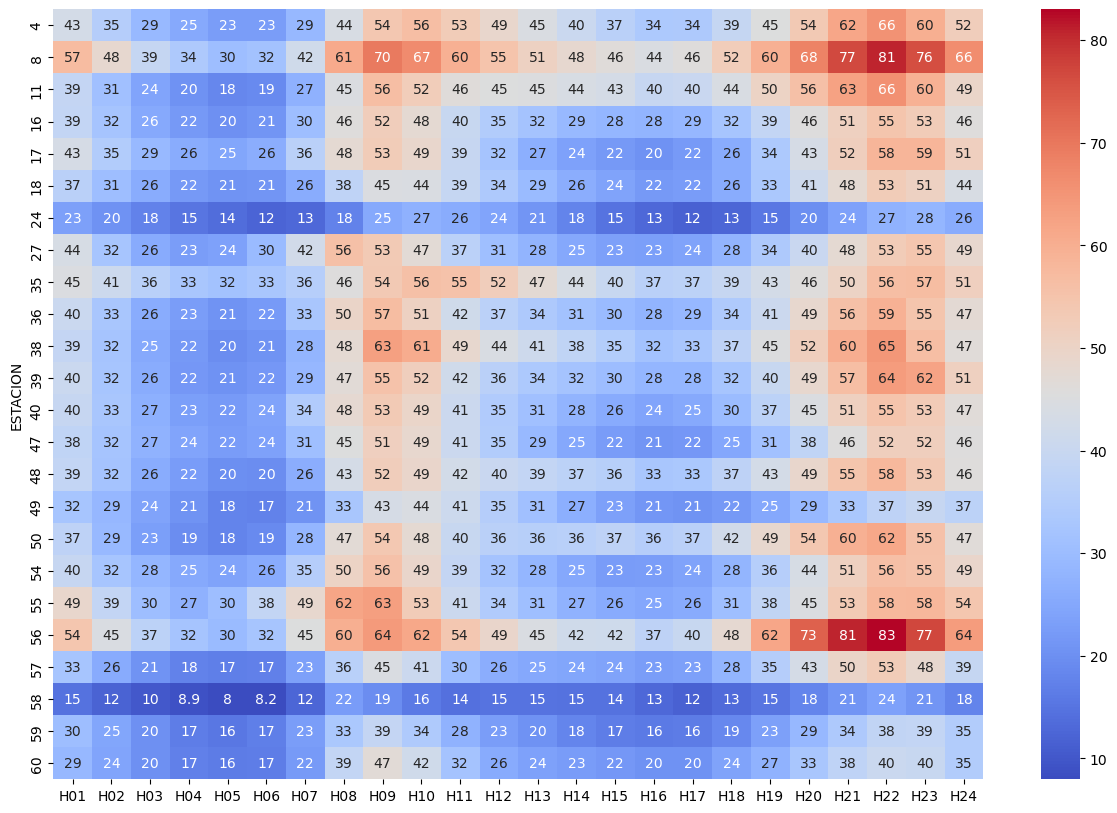

In [55]:
columnas_relevantes = [col for col in df_total.columns if col.startswith('H')]
df_agrupadas = df_total.groupby('ESTACION')[columnas_relevantes].mean()
# un grafico de calor para ver la relación entre las horas y las estaciones
plt.figure(figsize=(15, 10))
sns.heatmap(df_agrupadas, cmap='coolwarm', annot=True) # annot=True para que se muestren los valores en cada celda
plt.show()



Podemos sacar unas conclusiones rápidas a priori: vemos de manera sencilla en el anterior gráfico cómo dos estaciones resaltan por su medida tan baja de óxido de nitrógeno, que son la 24 (Casa de Campo) y 58 (El Pardo). Sabiendo que las demás estaciones están en ciertas partes de la ciudad de Madrid y que estas dos en concreto están en una zona muy verde y de parques, podemos concluir que la vegetación, el estar alejado del centro urbanístico de la ciudad y el no haber vehículos emitiendo gases afecta de manera considerable a una baja emisión de gases de óxido de nitrógeno.

Por su contraparte, podemos hacer una comparación inversa, viendo qué estaciones son las que más nivel de NO2 registran: 8 y 56. La primera, un lugar muy cercano a la M-30 de Madrid, autovía de uso elevado, y la segunda es en Plaza Elíptica, el sitio clave de la zona sur donde se concentra la mayor parte de tráfico de la ciudad por su cercanía con los pueblos de la zona sur de la capital.

Se podrían llegar a sacar muchas más conclusiones haciéndolo por mes, entre semana y semana, etc.

#### **Plantea cómo harías un modelo de predicción a 3 días vista de los niveles de NO2. No hace falta que lo programes, aunque si te sientes más cómodo, puedes hacerlo. Por ejemplo, puedes plantear: posibles variables a introducir, profundidad histórica de los datos, técnicas de modelado a probar**

In [63]:
#Plantea cómo harías un modelo de predicción a 3 días vista de los niveles de NO2 en cada estación.
# puedes plantear: posibles variables a introducir, profundidad histórica de los datos, técnicas de modelado a probar

# Variables a introducir:
# - La estación
# - La hora
# - El día de la semana

# Profundidad histórica de los datos: todos los datos que tengamos disponibles

# Técnicas de modelado a probar: regresión lineal y random forest
# - Regresión lineal: para ver si hay una relación lineal entre las variables y la variable objetivo
# - Random forest: para ver si hay una relación no lineal entre las variables y la variable objetivo

# vamos a hacer una predicción de los niveles de NO2 en cada estación para los próximos 3 días. Tendremos que hacer una prediccion de las medidas en cada hora, que son las medidas de H01 para la 1 de la mañana, H02 para las 2 de la mañana, etc.

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# primero vamos a hacer una predicción para una estación en concreto, que será la estación 8 
df_estacion = df_total[df_total['ESTACION'] == 8]
df_estacion = df_estacion.drop(columns = ['ESTACION'])
df_estacion = df_estacion.set_index(['DIA', 'MES'])
df_estacion

,,ANO,H01,H02,H03,H04,H05,H06,H07,H08,H09,...,H15,H16,H17,H18,H19,H20,H21,H22,H23,H24
DIA,MES,,,,,,,,,,,,,,,,,,,,,
1,1,2018,33.0,64.0,63.0,51.0,57.0,45.0,51.0,58.0,53.0,...,31.0,31.0,38.0,46.0,47.0,56.0,64.0,60.0,54.0,34.0
3,1,2018,31.0,22.0,28.0,28.0,17.0,26.0,66.0,71.0,64.0,...,47.0,39.0,46.0,60.0,68.0,71.0,76.0,77.0,67.0,63.0
4,1,2018,60.0,54.0,35.0,34.0,22.0,24.0,34.0,47.0,53.0,...,52.0,42.0,48.0,51.0,62.0,66.0,65.0,65.0,59.0,51.0
5,1,2018,45.0,32.0,26.0,24.0,22.0,24.0,33.0,46.0,47.0,...,54.0,47.0,59.0,70.0,69.0,73.0,68.0,67.0,56.0,53.0
6,1,2018,54.0,51.0,37.0,18.0,20.0,20.0,19.0,21.0,26.0,...,62.0,52.0,48.0,54.0,64.0,82.0,81.0,74.0,56.0,41.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24,12,2018,87.0,78.0,62.0,46.0,46.0,49.0,44.0,42.0,46.0,...,72.0,81.0,76.0,70.0,87.0,110.0,103.0,110.0,87.0,58.0
25,12,2018,55.0,59.0,56.0,45.0,42.0,39.0,37.0,40.0,49.0,...,68.0,68.0,65.0,65.0,87.0,98.0,87.0,92.0,94.0,77.0
28,12,2018,104.0,100.0,73.0,61.0,54.0,49.0,57.0,77.0,83.0,...,56.0,54.0,59.0,78.0,86.0,97.0,91.0,81.0,66.0,57.0


In [70]:
# estos son los datos de la estación 8 que vamos a usar para hacer la predicción
# ahora, quiero hacer una predicción para los próximos 3 días utilizando todos los datos que tenemos disponibles

# primero, vamos a hacer una predicción para la hora H01
X = df_estacion.drop(columns = ['H01'])
y = df_estacion['H01']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# regresión lineal
lr = LinearRegression()
lr.fit(X_train, y_train)
lr.score(X_test, y_test)


0.8364123427315915

,ANO,MES,DIA,H01,H02,H03,H04,H05,H06,H07,...,H15,H16,H17,H18,H19,H20,H21,H22,H23,H24
0,2018,1,1,33.0,64.0,63.0,51.0,57.0,45.0,51.0,...,31.0,31.0,38.0,46.0,47.0,56.0,64.0,60.0,54.0,34.0
1,2018,1,3,31.0,22.0,28.0,28.0,17.0,26.0,66.0,...,47.0,39.0,46.0,60.0,68.0,71.0,76.0,77.0,67.0,63.0
2,2018,1,4,60.0,54.0,35.0,34.0,22.0,24.0,34.0,...,52.0,42.0,48.0,51.0,62.0,66.0,65.0,65.0,59.0,51.0
3,2018,1,5,45.0,32.0,26.0,24.0,22.0,24.0,33.0,...,54.0,47.0,59.0,70.0,69.0,73.0,68.0,67.0,56.0,53.0
4,2018,1,6,54.0,51.0,37.0,18.0,20.0,20.0,19.0,...,62.0,52.0,48.0,54.0,64.0,82.0,81.0,74.0,56.0,41.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
333,2018,12,24,87.0,78.0,62.0,46.0,46.0,49.0,44.0,...,72.0,81.0,76.0,70.0,87.0,110.0,103.0,110.0,87.0,58.0
334,2018,12,25,55.0,59.0,56.0,45.0,42.0,39.0,37.0,...,68.0,68.0,65.0,65.0,87.0,98.0,87.0,92.0,94.0,77.0
335,2018,12,28,104.0,100.0,73.0,61.0,54.0,49.0,57.0,...,56.0,54.0,59.0,78.0,86.0,97.0,91.0,81.0,66.0,57.0
336,2018,12,29,57.0,62.0,46.0,42.0,30.0,29.0,33.0,...,32.0,29.0,35.0,49.0,83.0,110.0,133.0,90.0,69.0,52.0


In [58]:
# ahora quiero poder hacer un modelo de predicción a 3 días vista de la calidad del aire en la ciudad de Madrid de los niveles de NO2
# para ello, vamos a hacer un modelo de regresión lineal, y vamos a hacer un modelo por cada estación de medición con scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression


In [59]:

# vamos a hacer un modelo de regresión lineal por cada estación de medición
estaciones = df_total['ESTACION'].unique()
for estacion in estaciones:
    df_estacion = df_total[df_total['ESTACION'] == estacion]
    X = df_estacion[columnas_relevantes]
    y = df_estacion['H08']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    y_pred = lr.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    print(f'Estación: {estacion}, MSE: {mse}')
    

Estación: 4, MSE: 1.3749620189172172e-27
Estación: 8, MSE: 4.197528876681004e-27
Estación: 11, MSE: 2.4640503692540325e-26
Estación: 16, MSE: 7.209208232309273e-27
Estación: 17, MSE: 2.1366770934454236e-26
Estación: 18, MSE: 1.6354982186212777e-26
Estación: 24, MSE: 7.522775543291584e-27
Estación: 27, MSE: 1.3748459436697348e-26
Estación: 35, MSE: 2.8844579475026718e-27
Estación: 36, MSE: 3.0568348807872704e-26
Estación: 38, MSE: 1.0333863739006695e-26
Estación: 39, MSE: 1.558943335166376e-26
Estación: 40, MSE: 7.212081939892578e-27
Estación: 47, MSE: 1.975682701422562e-26
Estación: 48, MSE: 1.0146317852235679e-26
Estación: 49, MSE: 3.2289521243902757e-27
Estación: 50, MSE: 1.9435221675514944e-26
Estación: 54, MSE: 4.7354159387942513e-26
Estación: 55, MSE: 5.674493991475749e-26
Estación: 56, MSE: 9.566024588645289e-27
Estación: 57, MSE: 1.0542145556868048e-26
Estación: 58, MSE: 2.521610787701219e-27
Estación: 59, MSE: 1.4395009834616488e-26
Estación: 60, MSE: 1.2580378729766791e-26


Estación: 60, MSE: 1.3749620189172172e-27


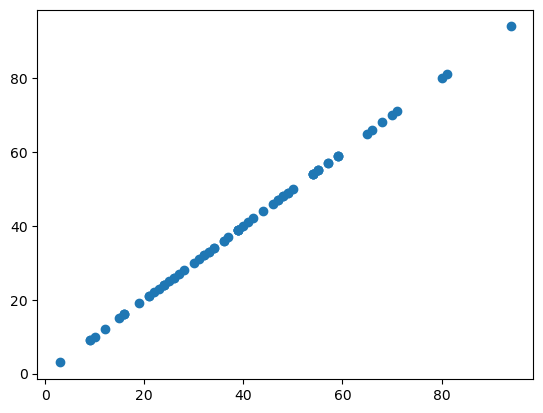

In [60]:
# vamos a hacer una prediccion
df_estacion = df_total[df_total['ESTACION'] == 4]
X = df_estacion[columnas_relevantes]
y = df_estacion['H08']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f'Estación: {estacion}, MSE: {mse}')
plt.scatter(y_test, y_pred)
plt.show()
